<a href="https://colab.research.google.com/github/lbnartey1/Walmart-Sales-Forecast/blob/main/Task7_Sales_Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries installation

In [14]:
!pip install -q xgboost lightgbm
print("Installation complete!")

Installation complete!


In [15]:
import os, warnings
warnings.filterwarnings('ignore')

# ── Data Analysis
import numpy as np
import pandas as pd

# ── Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ── Sklearn
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

# ── Tree boosting models
import xgboost as xgb
import lightgbm as lgb

# ── Time series tools
from statsmodels.tsa.seasonal import seasonal_decompose

print("All imports successful!")

All imports successful!


#Loading datasets.

In [16]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [17]:
DATA_DIR = "/content/drive/MyDrive/Elevvo Internship./Task 7 - Walmart Sales Forecast - Complete/Dataset"


TRAIN_PATH    = os.path.join(DATA_DIR, "train.csv")
FEATURES_PATH = os.path.join(DATA_DIR, "features.csv")
STORES_PATH   = os.path.join(DATA_DIR, "stores.csv")

# ── Check all files ───────────────────────────────────────────────────────────
for label, path in [("train.csv", TRAIN_PATH),
                    ("features.csv", FEATURES_PATH),
                    ("stores.csv", STORES_PATH)]:
    if os.path.exists(path):
        kb = os.path.getsize(path) / 1024
        print(f"✅  {label:<15} found   ({kb:.0f} KB)")
    else:
        print(f"⚠️  {label:<15} NOT found at: {path}")

✅  train.csv       found   (12542 KB)
✅  features.csv    found   (578 KB)
✅  stores.csv      found   (1 KB)


In [18]:
print("Scanning your Drive for Walmart CSV files...")
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    dirs[:] = [d for d in dirs if not d.startswith('.')]
    for f in files:
        if f.lower() in ['train.csv','features.csv','stores.csv']:
            print(f"Found: {os.path.join(root, f)}")

Scanning your Drive for Walmart CSV files...
Found: /content/drive/MyDrive/Elevvo Internship./Task 7 - Walmart Sales Forecast - Complete/Dataset/features.csv
Found: /content/drive/MyDrive/Elevvo Internship./Task 7 - Walmart Sales Forecast - Complete/Dataset/stores.csv
Found: /content/drive/MyDrive/Elevvo Internship./Task 7 - Walmart Sales Forecast - Complete/Dataset/train.csv


In [19]:
train_df = pd.read_csv(TRAIN_PATH, parse_dates=['Date'])

if os.path.exists(FEATURES_PATH):
    features_df = pd.read_csv(FEATURES_PATH, parse_dates=['Date'])
    print(f"features.csv loaded  — {features_df.shape}")
else:
    features_df = None
    print("features.csv not found — continuing without it")

if os.path.exists(STORES_PATH):
    stores_df = pd.read_csv(STORES_PATH)
    print(f"stores.csv loaded    — {stores_df.shape}")
else:
    stores_df = None
    print("stores.csv not found — continuing without it")

print(f"\ntrain.csv loaded     — {train_df.shape}")
print(f"Date range: {train_df['Date'].min().date()}  →  {train_df['Date'].max().date()}")
train_df.head(10)

features.csv loaded  — (8190, 12)
stores.csv loaded    — (45, 3)

train.csv loaded     — (421570, 5)
Date range: 2010-02-05  →  2012-10-26


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
5,1,1,2010-03-12,21043.39,False
6,1,1,2010-03-19,22136.64,False
7,1,1,2010-03-26,26229.21,False
8,1,1,2010-04-02,57258.43,False
9,1,1,2010-04-09,42960.91,False


Data Analysis

In [20]:
print("Column info:")
print(train_df.dtypes)
print()
print("Summary statistics:")
display(train_df.describe().round(2))

print("\nMissing values:")
print(train_df.isnull().sum().to_string())
print()
print(f"Unique stores      : {train_df['Store'].nunique()}")
print(f"Unique departments : {train_df['Dept'].nunique()}")
print(f"Total weeks        : {train_df['Date'].nunique()}")
print(f"Holiday weeks      : {train_df['IsHoliday'].sum()}")

Column info:
Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object

Summary statistics:


,Store,Dept,Date,Weekly_Sales
count,421570.00,421570.00,421570,421570.00
mean,22.20,44.26,2011-06-18 08:30:31.963375104,15981.26
min,1.00,1.00,2010-02-05 00:00:00,-4988.94
25%,11.00,18.00,2010-10-08 00:00:00,2079.65
50%,22.00,37.00,2011-06-17 00:00:00,7612.03
75%,33.00,74.00,2012-02-24 00:00:00,20205.85
max,45.00,99.00,2012-10-26 00:00:00,693099.36
std,12.79,30.49,NaN,22711.18



Missing values:
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0

Unique stores      : 45
Unique departments : 81
Total weeks        : 143
Holiday weeks      : 29661


Exploratory Data Analysis.

- How does total sales vary over time?
- Are there seasonal patterns (peaks at Christmas, Thanksgiving)?
- Do holiday weeks spike sales?
- Which stores and departments sell the most?

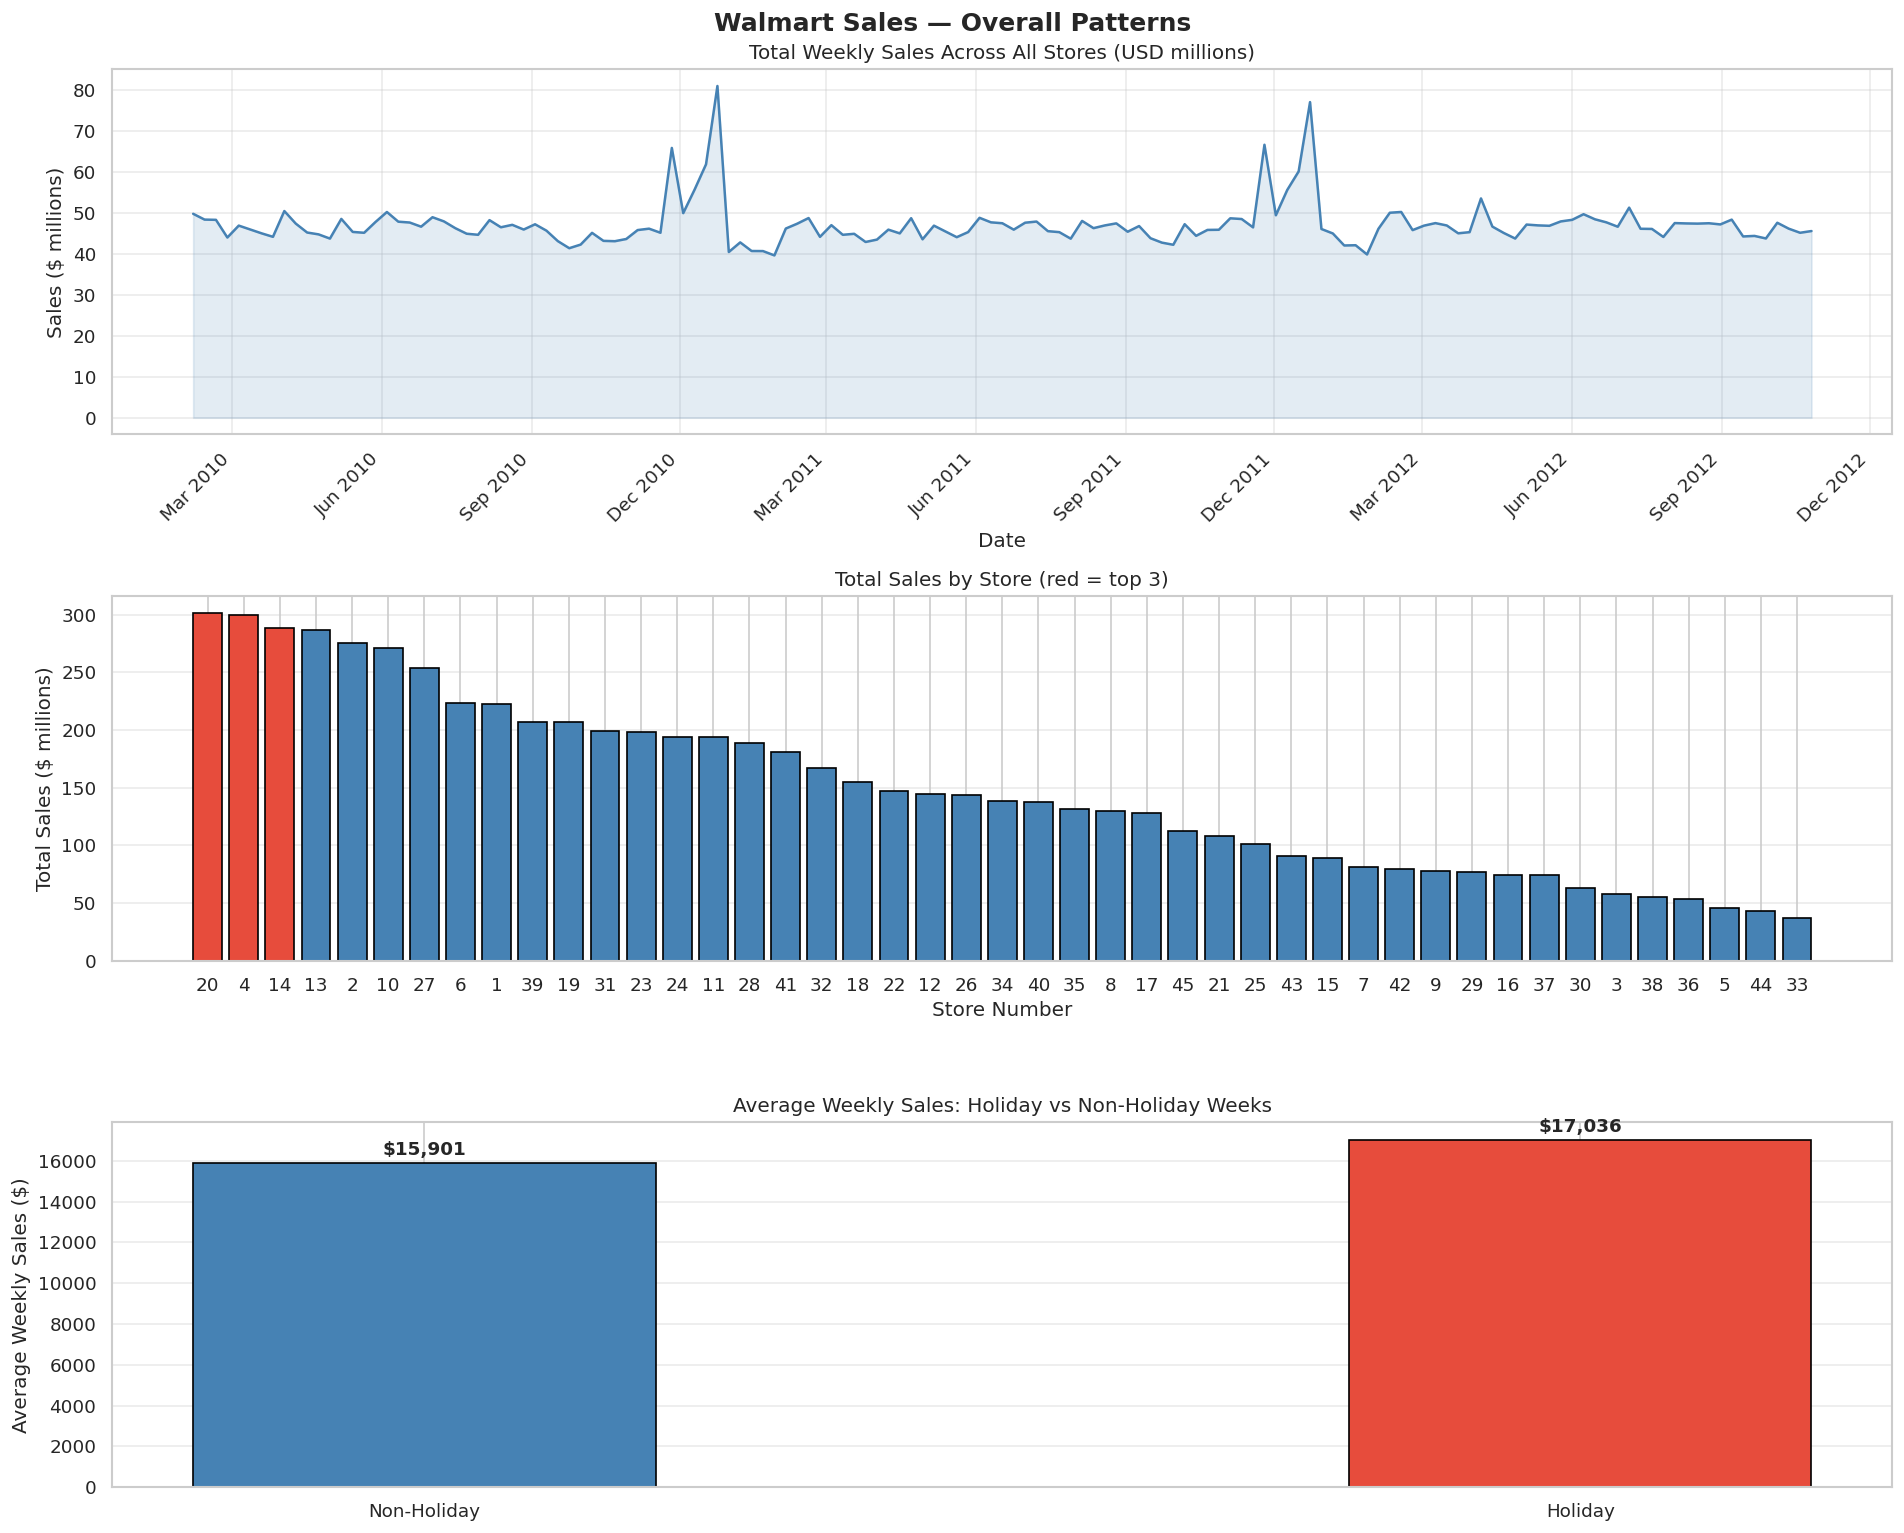

✅ Saved → Google Drive: sales_eda_overview.png


In [21]:
# ── Aggregate: total weekly sales across all stores
total_weekly = (train_df.groupby('Date')['Weekly_Sales']
                .sum()
                .reset_index()
                .rename(columns={'Weekly_Sales':'Total_Sales'}))

fig, axes = plt.subplots(3, 1, figsize=(16, 13))
fig.suptitle("Walmart Sales — Overall Patterns", fontsize=15, fontweight='bold')

# 1. Total sales over time
ax = axes[0]
ax.plot(total_weekly['Date'], total_weekly['Total_Sales']/1e6,
        color='steelblue', linewidth=1.5)
ax.fill_between(total_weekly['Date'], total_weekly['Total_Sales']/1e6,
                alpha=0.15, color='steelblue')
ax.set_title("Total Weekly Sales Across All Stores (USD millions)")
ax.set_xlabel("Date"); ax.set_ylabel("Sales ($ millions)")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.grid(alpha=0.4)

# 2. Sales by store (top 10)
ax = axes[1]
store_totals = train_df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
colors = ['#E74C3C' if i < 3 else 'steelblue' for i in range(len(store_totals))]
ax.bar(store_totals.index.astype(str), store_totals.values/1e6, color=colors, edgecolor='black')
ax.set_title("Total Sales by Store (red = top 3)")
ax.set_xlabel("Store Number"); ax.set_ylabel("Total Sales ($ millions)")
ax.grid(axis='y', alpha=0.4)

# 3. Holiday vs non-holiday
ax = axes[2]
holiday_sales = train_df.groupby('IsHoliday')['Weekly_Sales'].mean()
bars = ax.bar(['Non-Holiday', 'Holiday'], holiday_sales.values,
              color=['steelblue','#E74C3C'], edgecolor='black', width=0.4)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+200,
            f"${b.get_height():,.0f}", ha='center', va='bottom', fontweight='bold')
ax.set_title("Average Weekly Sales: Holiday vs Non-Holiday Weeks")
ax.set_ylabel("Average Weekly Sales ($)"); ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/sales_eda_overview.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: sales_eda_overview.png")

✅ Store 1 data ready
   Weeks    : 143
   Date range: 2010-02-05 → 2012-10-26
   Avg weekly sales: $1,555,264
   Max weekly sales: $2,387,950


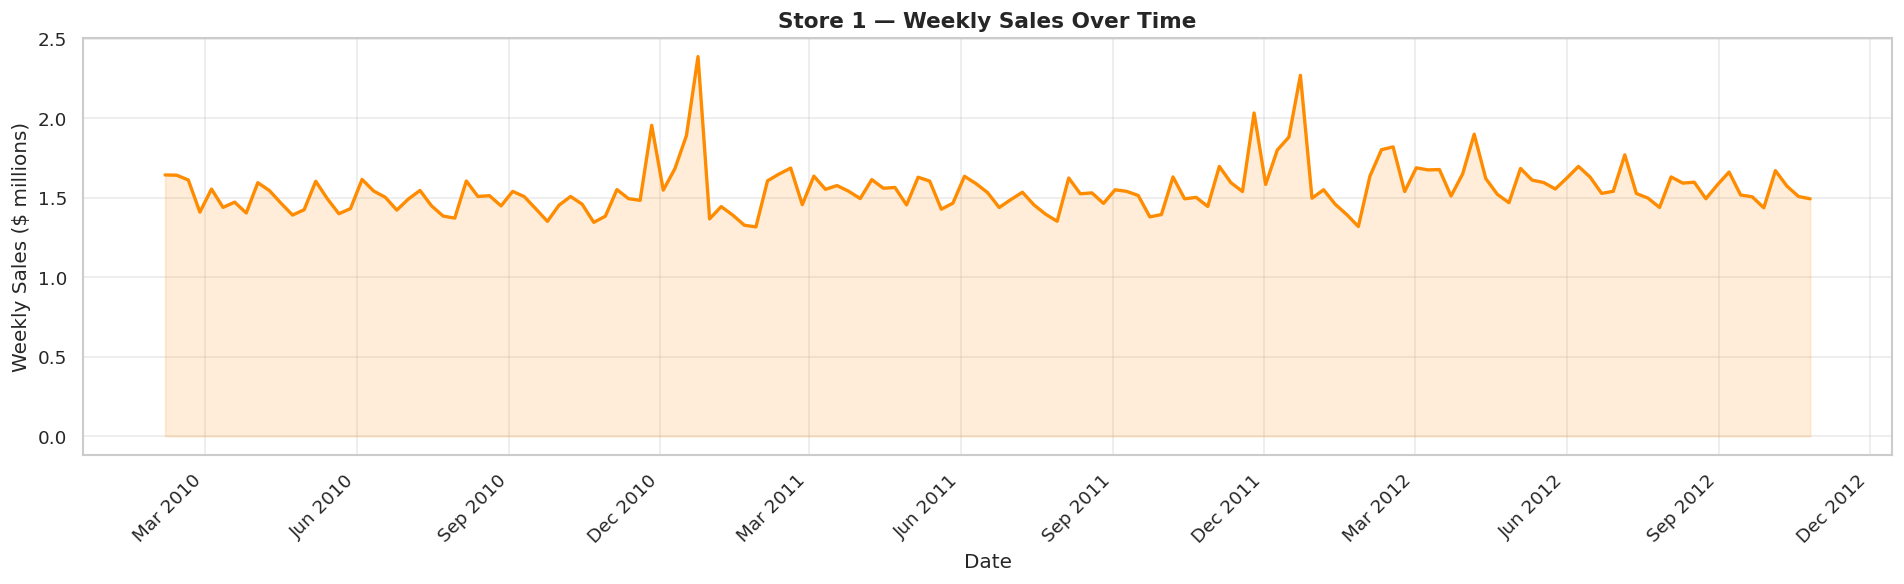

✅ Saved → Google Drive: store_sales_timeseries.png


In [22]:
# ── Focus on Store 1 for the rest of the analysis ────────────────────────────
# (Change STORE_ID to any store 1–45 if you want to analyse a different one)
STORE_ID = 1

store_df = (train_df[train_df['Store'] == STORE_ID]
            .groupby('Date')['Weekly_Sales']
            .sum()
            .reset_index()
            .rename(columns={'Weekly_Sales':'Sales'})
            .sort_values('Date')
            .reset_index(drop=True))

print(f"✅ Store {STORE_ID} data ready")
print(f"   Weeks    : {len(store_df)}")
print(f"   Date range: {store_df['Date'].min().date()} → {store_df['Date'].max().date()}")
print(f"   Avg weekly sales: ${store_df['Sales'].mean():,.0f}")
print(f"   Max weekly sales: ${store_df['Sales'].max():,.0f}")

plt.figure(figsize=(16, 5))
plt.plot(store_df['Date'], store_df['Sales']/1e6, color='darkorange', linewidth=2)
plt.fill_between(store_df['Date'], store_df['Sales']/1e6, alpha=0.15, color='darkorange')
plt.title(f"Store {STORE_ID} — Weekly Sales Over Time", fontsize=13, fontweight='bold')
plt.xlabel("Date"); plt.ylabel("Weekly Sales ($ millions)")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/store_sales_timeseries.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: store_sales_timeseries.png")

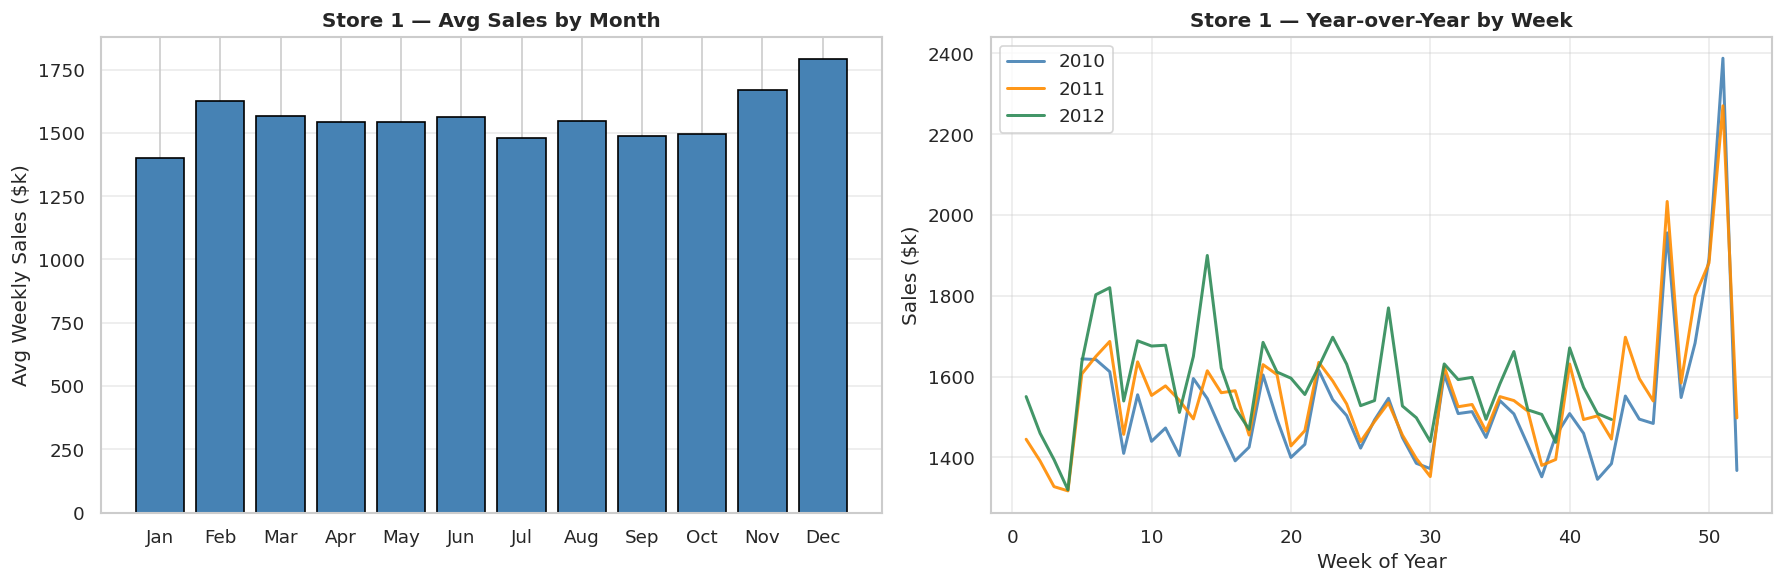

✅ Saved → Google Drive: sales_seasonality.png


In [23]:
# Monthly and weekly seasonality patterns
store_df['Month']     = store_df['Date'].dt.month
store_df['DayOfWeek'] = store_df['Date'].dt.dayofweek
store_df['Week']      = store_df['Date'].dt.isocalendar().week.astype(int)
store_df['Year']      = store_df['Date'].dt.year

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# By month
monthly_avg = store_df.groupby('Month')['Sales'].mean()
axes[0].bar(range(1,13), monthly_avg.values/1e3, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(MONTH_NAMES)
axes[0].set_title(f"Store {STORE_ID} — Avg Sales by Month", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Avg Weekly Sales ($k)"); axes[0].grid(axis='y', alpha=0.4)

# Year-over-year overlay
for yr, color in zip(store_df['Year'].unique(), ['steelblue','darkorange','seagreen']):
    yr_data = store_df[store_df['Year']==yr]
    axes[1].plot(yr_data['Week'], yr_data['Sales']/1e3,
                 label=str(yr), color=color, linewidth=1.8, alpha=0.9)
axes[1].set_title(f"Store {STORE_ID} — Year-over-Year by Week", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Week of Year"); axes[1].set_ylabel("Sales ($k)")
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/sales_seasonality.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: sales_seasonality.png")

Bonus: Seasonal Decomposition

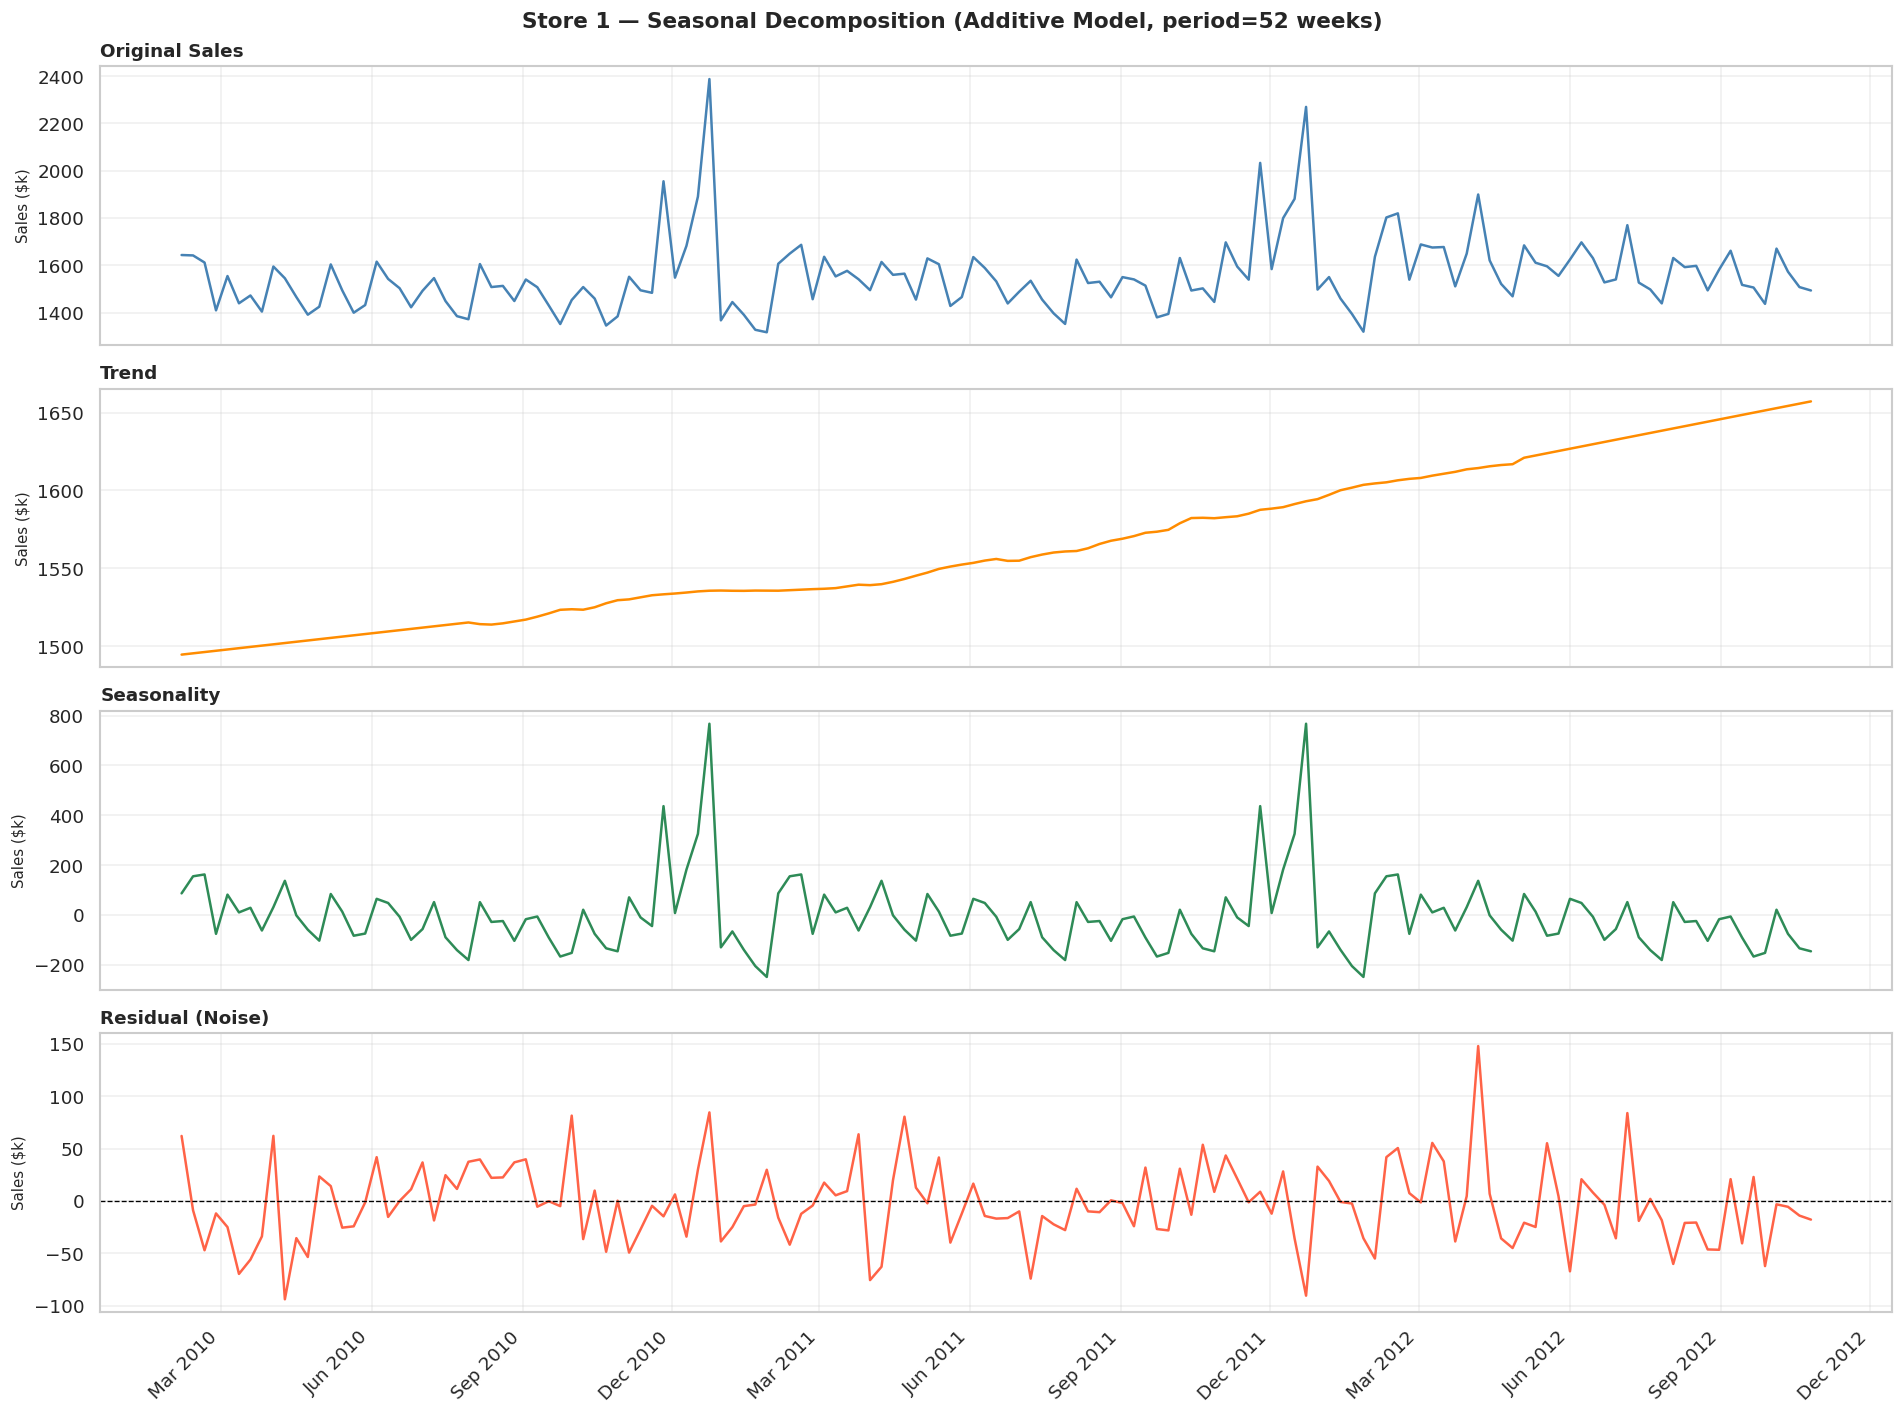

✅ Saved → Google Drive: seasonal_decomposition.png

📏 Seasonality strength: 0.939  (0 = none, 1 = very strong)
   > 0.6 = strong seasonality — seasonal features will be very helpful for forecasting


In [24]:
# Seasonal decomposition requires evenly-spaced data with no gaps
# period=52 means we expect one full cycle per 52 weeks (annual seasonality)
sales_series = store_df.set_index('Date')['Sales']

decomp = seasonal_decompose(sales_series, model='additive', period=52, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
fig.suptitle(f"Store {STORE_ID} — Seasonal Decomposition (Additive Model, period=52 weeks)",
             fontsize=13, fontweight='bold')

components = [
    (sales_series,       'Original Sales',  'steelblue'),
    (decomp.trend,       'Trend',           'darkorange'),
    (decomp.seasonal,    'Seasonality',     'seagreen'),
    (decomp.resid,       'Residual (Noise)','tomato'),
]
for ax, (data, title, color) in zip(axes, components):
    ax.plot(data.index, data.values/1e3, color=color, linewidth=1.5)
    ax.set_ylabel("Sales ($k)", fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold', loc='left')
    ax.grid(alpha=0.3)
    if title == 'Residual (Noise)':
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/seasonal_decomposition.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: seasonal_decomposition.png")

# Seasonality strength metric
var_resid   = np.var(decomp.resid.dropna())
var_detrend = np.var((sales_series - decomp.trend).dropna())
strength = max(0, 1 - var_resid / var_detrend)
print(f"\n📏 Seasonality strength: {strength:.3f}  (0 = none, 1 = very strong)")
print("   > 0.6 = strong seasonality — seasonal features will be very helpful for forecasting")

Feature Engineering

In [25]:
def engineer_features(df):
    """
    Creates all time-based, lag, and rolling features from a sales DataFrame.
    Input must have columns: Date, Sales (sorted by Date, no gaps).
    """
    df = df.copy().sort_values('Date').reset_index(drop=True)

    # ── Calendar features ─────────────────────────────────────────────────────
    df['Year']       = df['Date'].dt.year
    df['Month']      = df['Date'].dt.month
    df['Week']       = df['Date'].dt.isocalendar().week.astype(int)
    df['Quarter']    = df['Date'].dt.quarter
    df['DayOfYear']  = df['Date'].dt.dayofyear

    # Cyclical encoding for Month and Week
    # sin/cos encoding preserves the cyclic nature: Jan and Dec are neighbours
    df['Month_sin']  = np.sin(2 * np.pi * df['Month'] / 12)
    df['Month_cos']  = np.cos(2 * np.pi * df['Month'] / 12)
    df['Week_sin']   = np.sin(2 * np.pi * df['Week'] / 52)
    df['Week_cos']   = np.cos(2 * np.pi * df['Week'] / 52)

    # Is it a holiday-heavy month? (Nov & Dec drive massive Walmart sales)
    df['IsHolidaySeason'] = df['Month'].isin([11, 12]).astype(int)

    # ── Lag features ──────────────────────────────────────────────────────────
    for lag in [1, 2, 3, 4, 8, 12, 26, 52]:
        df[f'lag_{lag}'] = df['Sales'].shift(lag)

    # ── Rolling window features ───────────────────────────────────────────────
    for window in [4, 8, 12, 26]:
        df[f'rolling_mean_{window}'] = df['Sales'].shift(1).rolling(window).mean()
        df[f'rolling_std_{window}']  = df['Sales'].shift(1).rolling(window).std()
        df[f'rolling_max_{window}']  = df['Sales'].shift(1).rolling(window).max()
        df[f'rolling_min_{window}']  = df['Sales'].shift(1).rolling(window).min()

    # ── Trend feature ──────────────────────────────────────────────────────────
    df['TimeIndex'] = np.arange(len(df))  # Simple linear time index (0, 1, 2, ...)

    return df

store_df = engineer_features(store_df)

# Drop rows with NaN (caused by lag/rolling on early rows)
store_df_clean = store_df.dropna().reset_index(drop=True)

FEATURE_COLS = [c for c in store_df_clean.columns
                if c not in ['Date','Sales','Year']]

print(f"   Features engineered!")
print(f"   Rows before dropping NaN : {len(store_df)}")
print(f"   Rows after  dropping NaN : {len(store_df_clean)}")
print(f"   Total features           : {len(FEATURE_COLS)}")
print(f"\nFeature list:")
for i, f in enumerate(FEATURE_COLS):
    print(f"   {i+1:>2}. {f}")

   Features engineered!
   Rows before dropping NaN : 143
   Rows after  dropping NaN : 91
   Total features           : 35

Feature list:
    1. Month
    2. DayOfWeek
    3. Week
    4. Quarter
    5. DayOfYear
    6. Month_sin
    7. Month_cos
    8. Week_sin
    9. Week_cos
   10. IsHolidaySeason
   11. lag_1
   12. lag_2
   13. lag_3
   14. lag_4
   15. lag_8
   16. lag_12
   17. lag_26
   18. lag_52
   19. rolling_mean_4
   20. rolling_std_4
   21. rolling_max_4
   22. rolling_min_4
   23. rolling_mean_8
   24. rolling_std_8
   25. rolling_max_8
   26. rolling_min_8
   27. rolling_mean_12
   28. rolling_std_12
   29. rolling_max_12
   30. rolling_min_12
   31. rolling_mean_26
   32. rolling_std_26
   33. rolling_max_26
   34. rolling_min_26
   35. TimeIndex


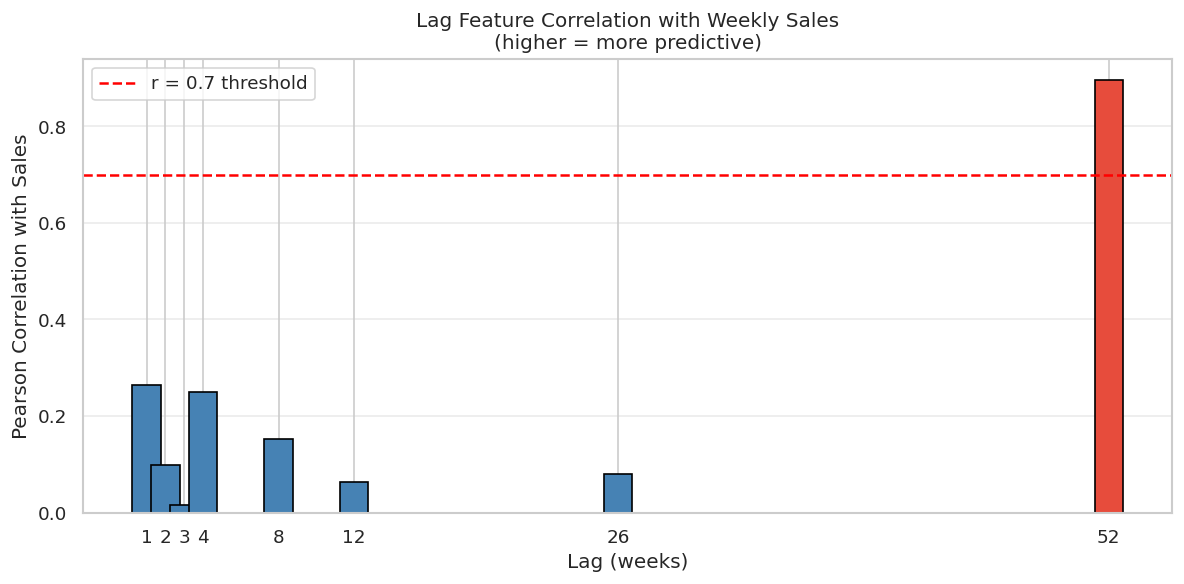

✅ Saved → Google Drive: lag_correlations.png


In [26]:
# ── Visualise lag correlations ─────────────────────────────────────────────────
lag_cols = [c for c in store_df_clean.columns if c.startswith('lag_')]
corrs    = [store_df_clean['Sales'].corr(store_df_clean[c]) for c in lag_cols]
lag_nums = [int(c.split('_')[1]) for c in lag_cols]

plt.figure(figsize=(10, 5))
plt.bar(lag_nums, corrs, color=['#E74C3C' if c > 0.7 else 'steelblue' for c in corrs],
        edgecolor='black', width=1.5)
plt.axhline(0.7, color='red', linestyle='--', linewidth=1.5, label='r = 0.7 threshold')
plt.xlabel("Lag (weeks)"); plt.ylabel("Pearson Correlation with Sales")
plt.title("Lag Feature Correlation with Weekly Sales\n(higher = more predictive)", fontsize=12)
plt.xticks(lag_nums); plt.legend(); plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/lag_correlations.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: lag_correlations.png")

Train-Test split

✅ Train/test split (chronological)
   Train: 78 weeks  (2011-02-04 → 2012-07-27)
   Test : 13  weeks  (2012-08-03  → 2012-10-26)


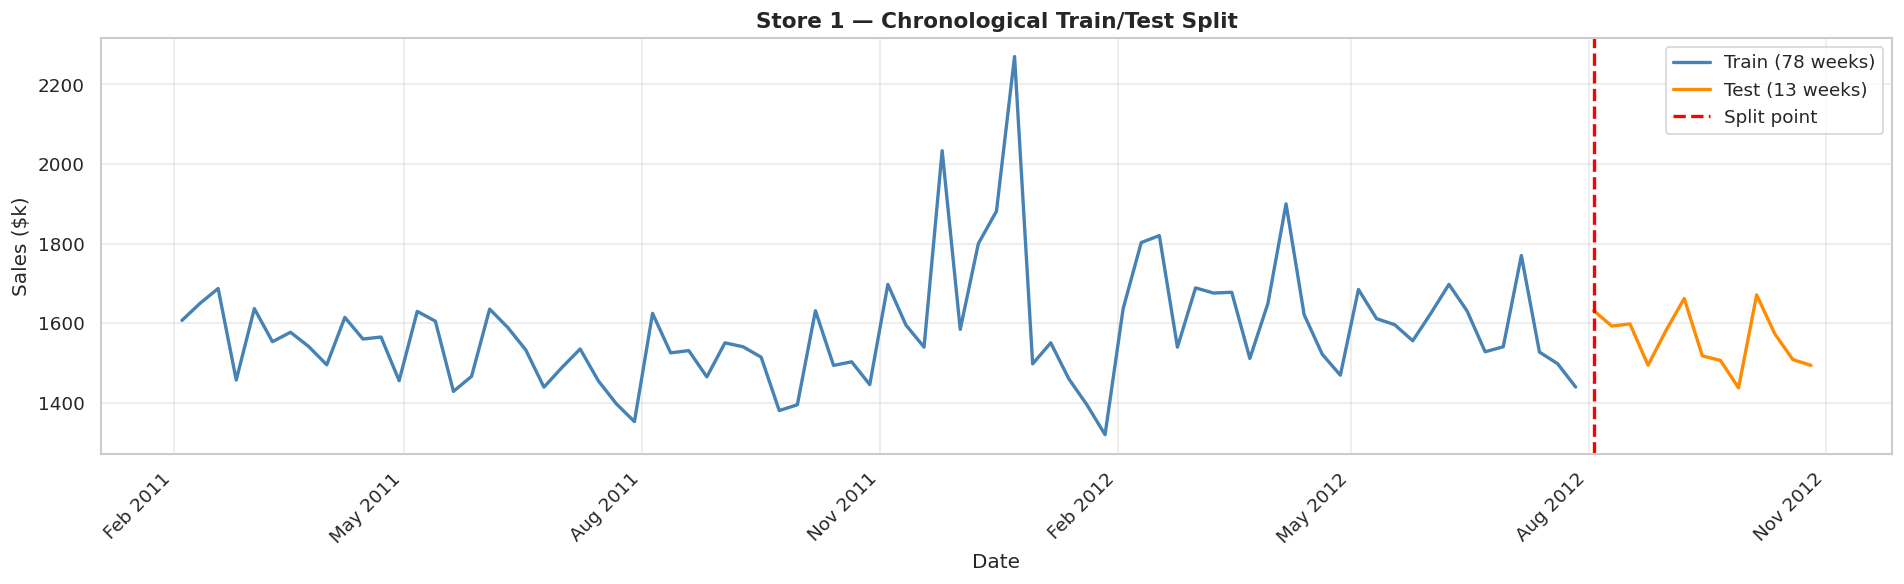

✅ Saved → Google Drive: train_test_split.png


In [27]:
# Use the last 3 months (≈13 weeks) as the test set
TEST_WEEKS  = 13
split_idx   = len(store_df_clean) - TEST_WEEKS

train = store_df_clean.iloc[:split_idx].copy()
test  = store_df_clean.iloc[split_idx:].copy()

X_train = train[FEATURE_COLS].values
y_train = train['Sales'].values
X_test  = test[FEATURE_COLS].values
y_test  = test['Sales'].values

print(f"✅ Train/test split (chronological)")
print(f"   Train: {len(train)} weeks  ({train['Date'].min().date()} → {train['Date'].max().date()})")
print(f"   Test : {len(test)}  weeks  ({test['Date'].min().date()}  → {test['Date'].max().date()})")

# Visualise the split
plt.figure(figsize=(16, 5))
plt.plot(train['Date'], train['Sales']/1e3, color='steelblue', lw=2, label=f'Train ({len(train)} weeks)')
plt.plot(test['Date'],  test['Sales']/1e3,  color='darkorange', lw=2, label=f'Test ({len(test)} weeks)')
plt.axvline(test['Date'].iloc[0], color='red', linestyle='--', lw=2, label='Split point')
plt.title(f"Store {STORE_ID} — Chronological Train/Test Split", fontsize=13, fontweight='bold')
plt.xlabel("Date"); plt.ylabel("Sales ($k)")
plt.legend(); plt.grid(alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/train_test_split.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: train_test_split.png")

Evaluation Metrics

In [28]:
def evaluate(name, y_true, y_pred, results_dict=None):
    """
    Calculates and prints MAE, RMSE, MAPE, and R² for a model.

    MAE  (Mean Absolute Error)      — average dollar error (easy to interpret)
    RMSE (Root Mean Squared Error)  — penalises large errors more heavily
    MAPE (Mean Absolute % Error)    — % error, scale-independent
    R²   (R-squared)                — % of variance explained (1.0 = perfect)
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    r2   = r2_score(y_true, y_pred)

    print(f"  {'Model':<25}: MAE=${mae:>10,.0f}  RMSE=${rmse:>10,.0f}  MAPE={mape:>6.2f}%  R²={r2:.4f}")

    if results_dict is not None:
        results_dict[name] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2,
                              'Predictions': y_pred}
    return mae, rmse, mape, r2

RESULTS = {}   # Stores results from all models for final comparison
print("✅ Metrics helper ready!")

✅ Metrics helper ready!


Linear Regression and Ridge regression

  Model                    : MAE=$   104,959  RMSE=$   119,940  MAPE=  6.79%  R²=-2.0122
  Model                    : MAE=$    36,874  RMSE=$    44,928  MAPE=  2.36%  R²=0.5773



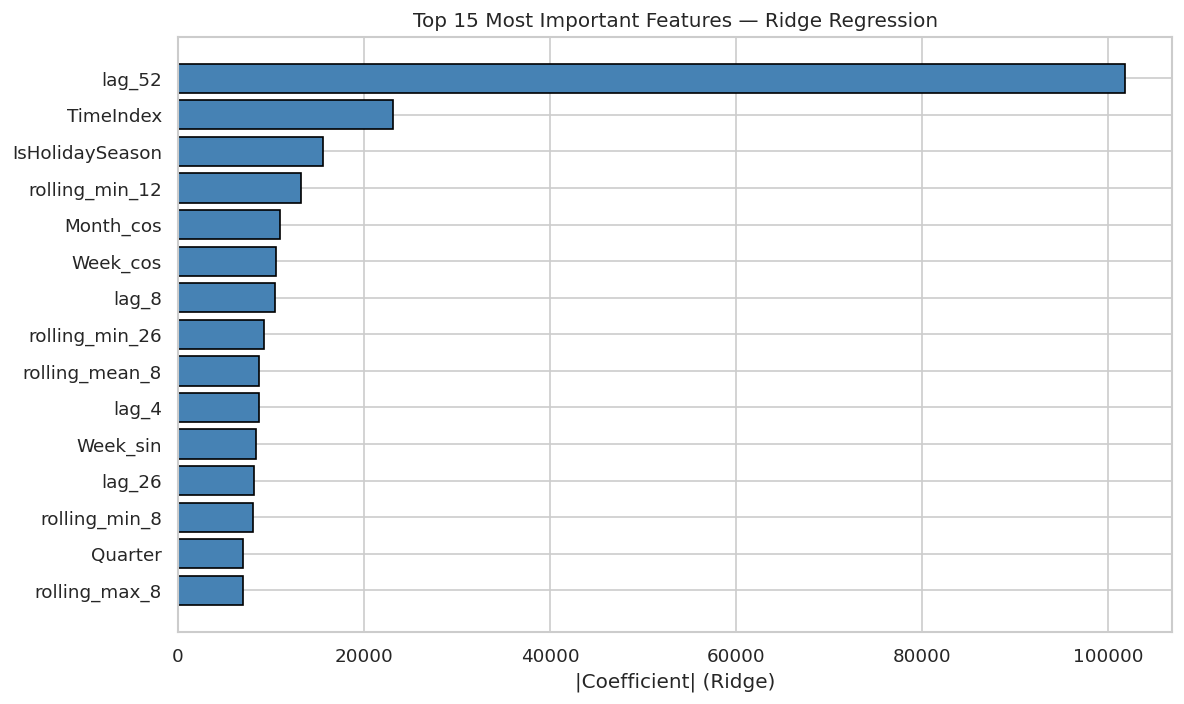

✅ Saved → Google Drive: ridge_importance.png


In [29]:
# Scale features
scaler  = StandardScaler()
Xtr_sc  = scaler.fit_transform(X_train)
Xte_sc  = scaler.transform(X_test)

# ── Linear Regression
lr = LinearRegression()
lr.fit(Xtr_sc, y_train)
evaluate("Linear Regression", y_test, lr.predict(Xte_sc), RESULTS)

# ── Ridge Regression
ridge = Ridge(alpha=10.0)
ridge.fit(Xtr_sc, y_train)
evaluate("Ridge Regression", y_test, ridge.predict(Xte_sc), RESULTS)

print()

# ── Feature importance for linear model
coef_df = pd.DataFrame({'Feature': FEATURE_COLS,
                        'Coefficient': np.abs(ridge.coef_)
                       }).sort_values('Coefficient', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1],
         color='steelblue', edgecolor='black')
plt.xlabel("|Coefficient| (Ridge)")
plt.title("Top 15 Most Important Features — Ridge Regression", fontsize=12)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ridge_importance.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: ridge_importance.png")

Random Forest Regressor

  Model                    : MAE=$    37,480  RMSE=$    43,299  MAPE=  2.42%  R²=0.6074


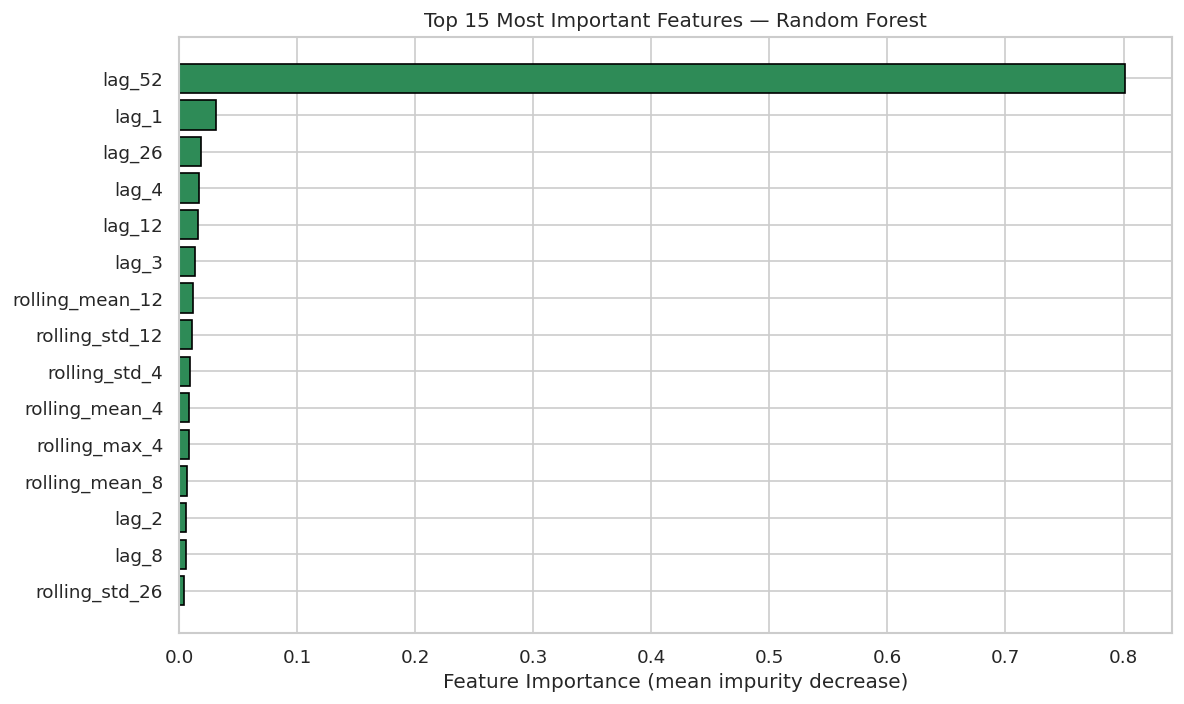

✅ Saved → Google Drive: rf_importance.png


In [30]:
rf = RandomForestRegressor(
    n_estimators=300,    # 300 decision trees
    max_depth=12,        # Limit tree depth to prevent overfitting
    min_samples_leaf=3,
    n_jobs=-1,           # Use all CPU cores
    random_state=42
)
rf.fit(X_train, y_train)
evaluate("Random Forest", y_test, rf.predict(X_test), RESULTS)

# Feature importance
fi_df = pd.DataFrame({'Feature': FEATURE_COLS,
                      'Importance': rf.feature_importances_
                     }).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
         color='seagreen', edgecolor='black')
plt.xlabel("Feature Importance (mean impurity decrease)")
plt.title("Top 15 Most Important Features — Random Forest", fontsize=12)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/rf_importance.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: rf_importance.png")

Bonus: XGBoost - Time Aware Validation

In [31]:
# Time-aware cross-validation to find good hyperparameters
tscv      = TimeSeriesSplit(n_splits=5)
cv_scores = []

print("Running TimeSeriesSplit cross-validation for XGBoost...")
for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train)):
    Xf_tr, Xf_va = X_train[tr_idx], X_train[va_idx]
    yf_tr, yf_va = y_train[tr_idx], y_train[va_idx]

    xgb_cv = xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.05,
        max_depth=6, subsample=0.8,
        colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, verbosity=0, n_jobs=-1
    )
    xgb_cv.fit(Xf_tr, yf_tr,
               eval_set=[(Xf_va, yf_va)],
               verbose=False)
    preds = xgb_cv.predict(Xf_va)
    mae   = mean_absolute_error(yf_va, preds)
    cv_scores.append(mae)
    print(f"   Fold {fold+1}: MAE = ${mae:,.0f}")

print(f"\n   CV Mean MAE: ${np.mean(cv_scores):,.0f} ± ${np.std(cv_scores):,.0f}")

# Train final XGBoost on all training data
xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=6, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, verbosity=0, n_jobs=-1
)
xgb_model.fit(X_train, y_train)
evaluate("XGBoost", y_test, xgb_model.predict(X_test), RESULTS)

Running TimeSeriesSplit cross-validation for XGBoost...
   Fold 1: MAE = $81,125
   Fold 2: MAE = $84,513
   Fold 3: MAE = $157,688
   Fold 4: MAE = $89,614
   Fold 5: MAE = $52,460

   CV Mean MAE: $93,080 ± $34,792
  Model                    : MAE=$    39,574  RMSE=$    48,166  MAPE=  2.58%  R²=0.5142


(39574.15038461541,
 np.float64(48165.88630152172),
 np.float64(2.583559371334012),
 0.5142187264676438)

Bonus: LightGBM

In [32]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=8, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, verbose=-1, n_jobs=-1
)

# Time-aware early stopping
tscv_lgb  = TimeSeriesSplit(n_splits=3)
lgb_cv_scores = []

print("Running TimeSeriesSplit CV for LightGBM...")
for fold, (tr_idx, va_idx) in enumerate(tscv_lgb.split(X_train)):
    lgb_cv = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05,
                                num_leaves=63, random_state=42,
                                verbose=-1, n_jobs=-1)
    lgb_cv.fit(X_train[tr_idx], y_train[tr_idx],
               eval_set=[(X_train[va_idx], y_train[va_idx])],
               callbacks=[lgb.early_stopping(50, verbose=False),
                          lgb.log_evaluation(period=-1)])
    mae = mean_absolute_error(y_train[va_idx], lgb_cv.predict(X_train[va_idx]))
    lgb_cv_scores.append(mae)
    print(f"   Fold {fold+1}: MAE = ${mae:,.0f}")

print(f"\n   CV Mean MAE: ${np.mean(lgb_cv_scores):,.0f} ± ${np.std(lgb_cv_scores):,.0f}")

# Train final LightGBM
lgb_model.fit(X_train, y_train)
evaluate("LightGBM", y_test, lgb_model.predict(X_test), RESULTS)

Running TimeSeriesSplit CV for LightGBM...
   Fold 1: MAE = $86,241
   Fold 2: MAE = $179,696
   Fold 3: MAE = $65,510

   CV Mean MAE: $110,482 ± $49,668
  Model                    : MAE=$    84,390  RMSE=$   104,308  MAPE=  5.47%  R²=-1.2782


(84390.0982818048,
 np.float64(104307.56166878786),
 np.float64(5.466938207311078),
 -1.2782073223028712)

Actual vrs Predicted

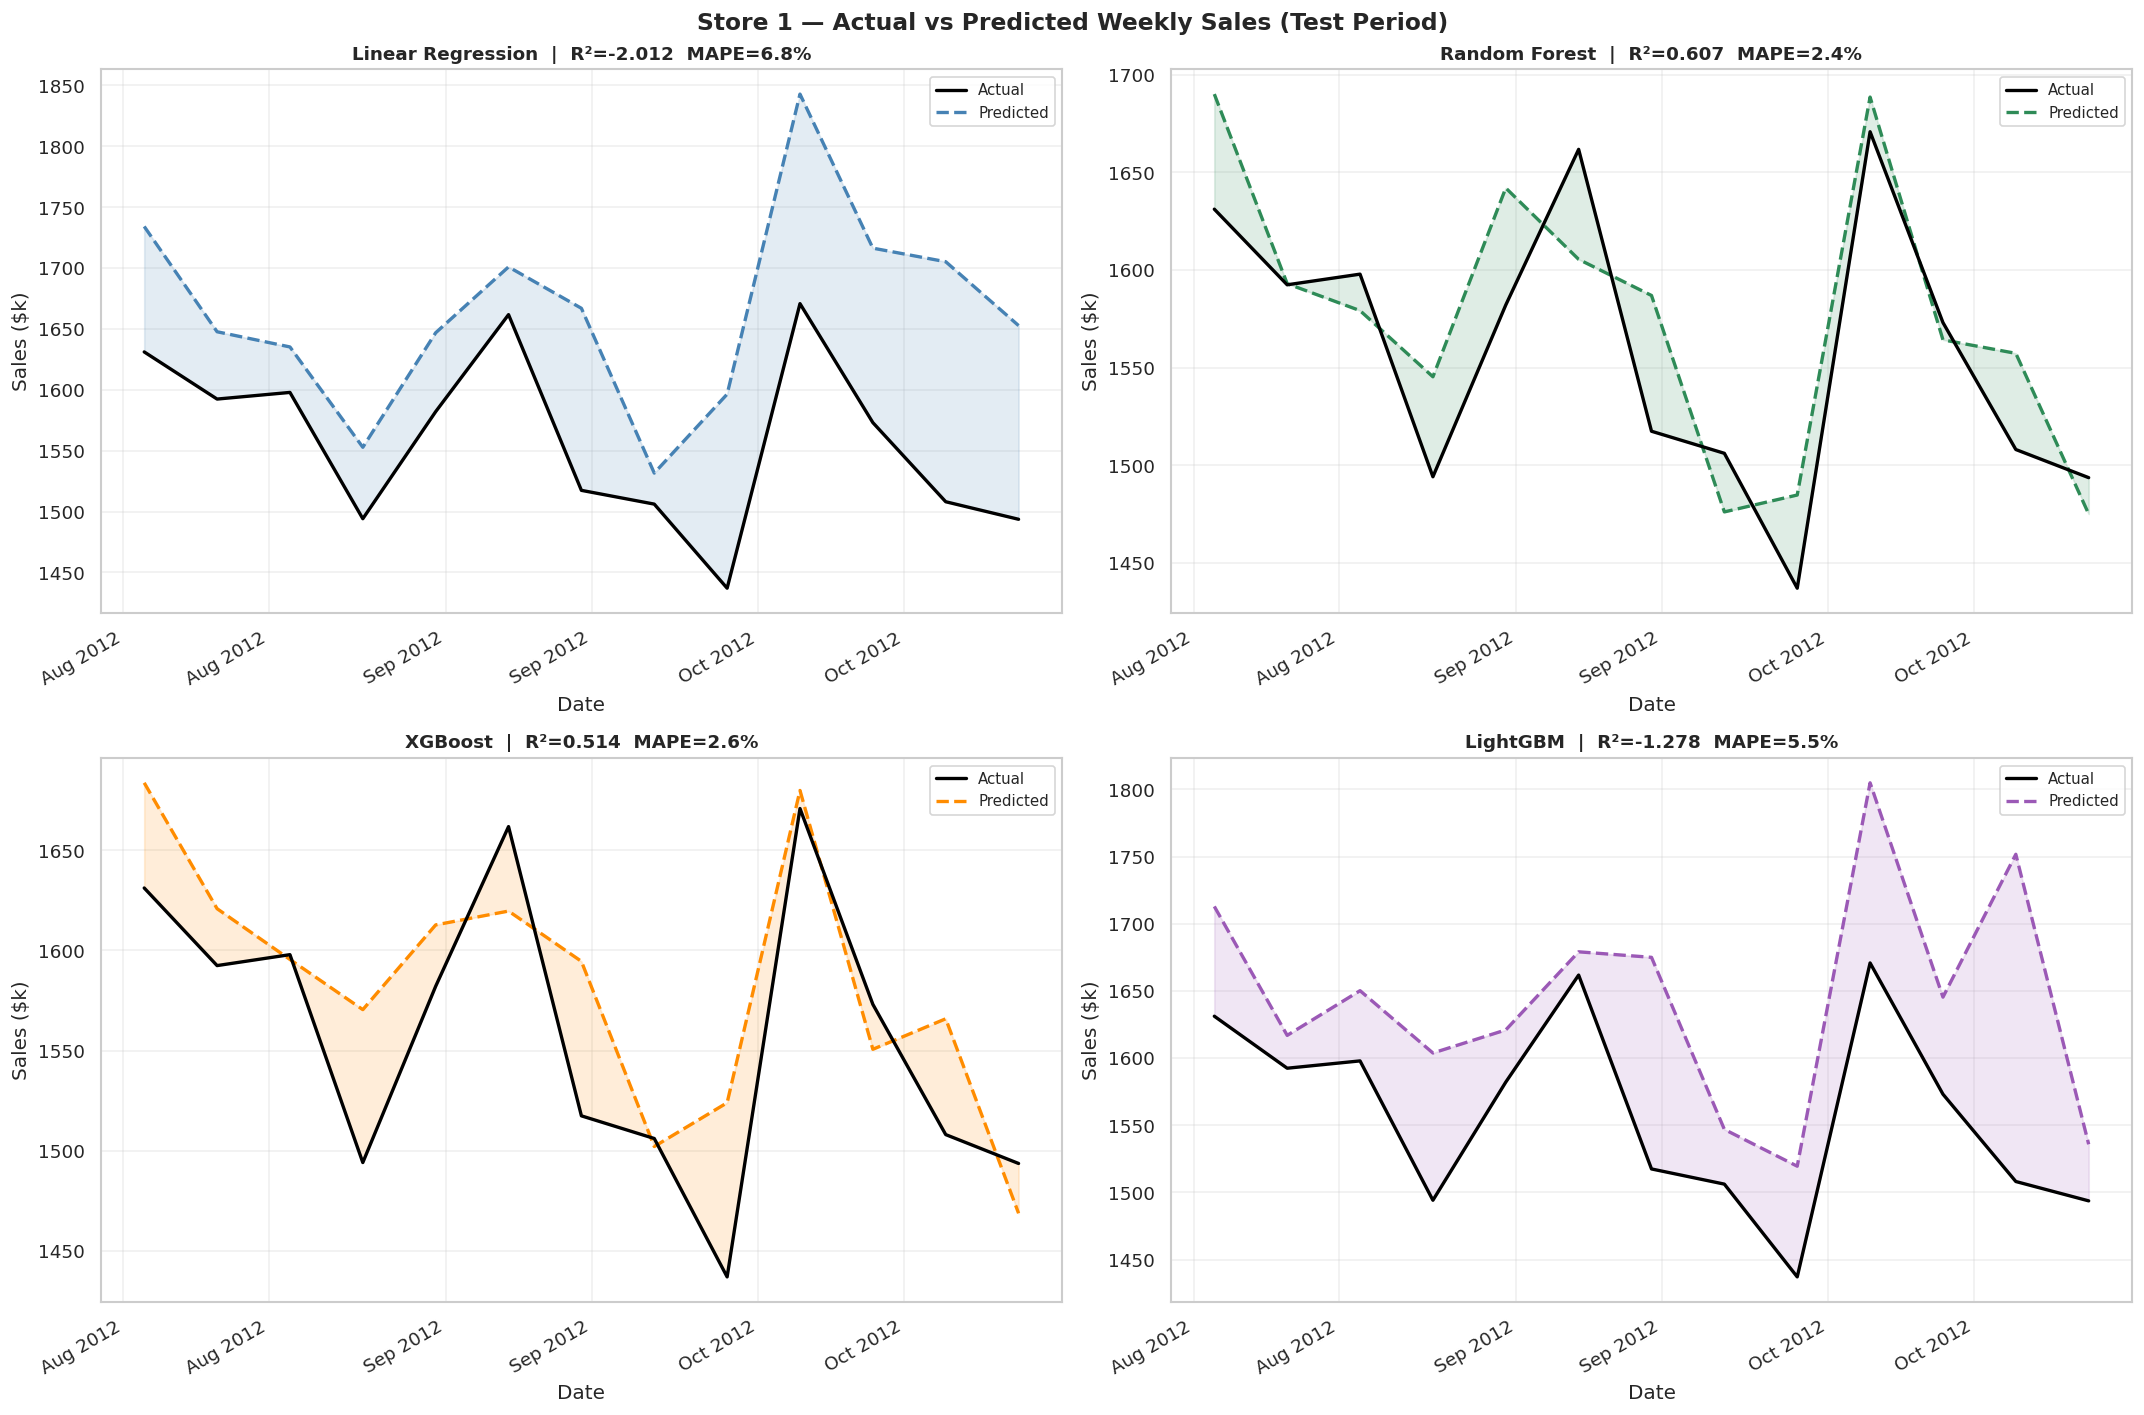

✅ Saved → Google Drive: actual_vs_predicted.png


In [33]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(f"Store {STORE_ID} — Actual vs Predicted Weekly Sales (Test Period)",
             fontsize=14, fontweight='bold')

model_order = ["Linear Regression", "Random Forest", "XGBoost", "LightGBM"]
colors      = ['steelblue', 'seagreen', 'darkorange', '#9B59B6']

for ax, (name, color) in zip(axes.flatten(), zip(model_order, colors)):
    if name not in RESULTS:
        ax.set_visible(False)
        continue
    preds = RESULTS[name]['Predictions']
    r2    = RESULTS[name]['R2']
    mape  = RESULTS[name]['MAPE']

    ax.plot(test['Date'], y_test/1e3,  color='black',  lw=2,   label='Actual',   zorder=3)
    ax.plot(test['Date'], preds/1e3,   color=color,    lw=2,   label='Predicted', linestyle='--', zorder=2)
    ax.fill_between(test['Date'], y_test/1e3, preds/1e3,
                    alpha=0.15, color=color)

    ax.set_title(f"{name}  |  R²={r2:.3f}  MAPE={mape:.1f}%", fontsize=11, fontweight='bold')
    ax.set_xlabel("Date"); ax.set_ylabel("Sales ($k)")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/actual_vs_predicted.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: actual_vs_predicted.png")

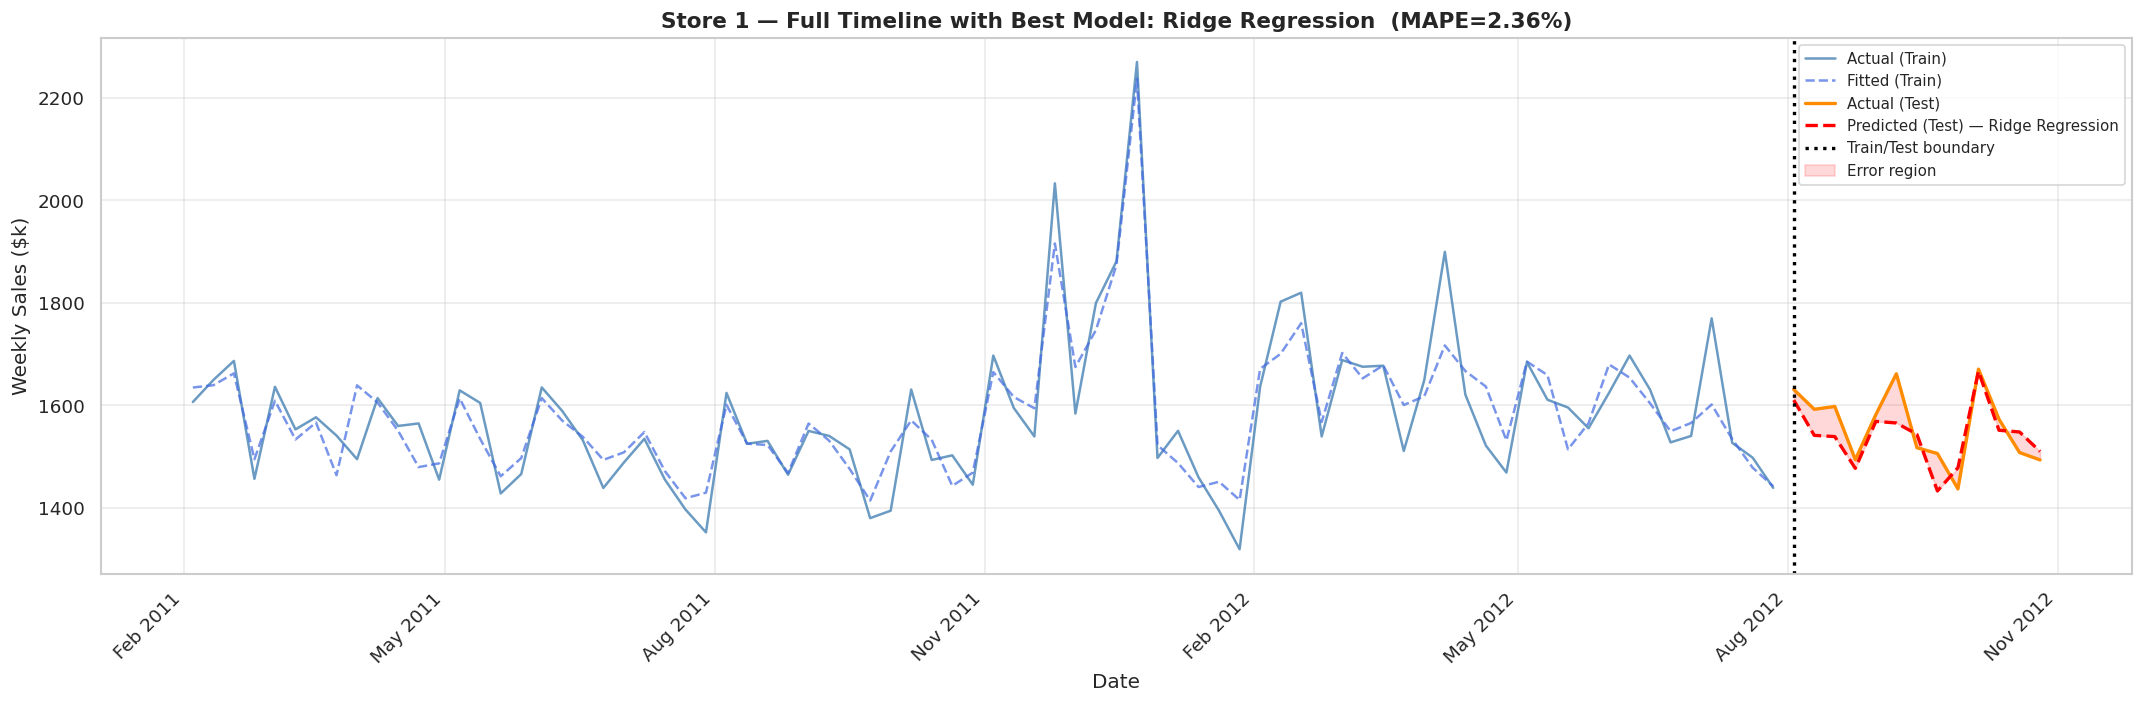

✅ Saved → Google Drive: full_timeline_best_model.png
   Best model: Ridge Regression  (MAPE = 2.36%)


In [34]:
# Full-timeline plot: training fit + test prediction for best model
best_name = min(RESULTS, key=lambda k: RESULTS[k]['MAPE'])
best_preds = RESULTS[best_name]['Predictions']

# Get training predictions for the best model too
if best_name == "Random Forest":
    train_preds = rf.predict(X_train)
elif best_name == "XGBoost":
    train_preds = xgb_model.predict(X_train)
elif best_name == "LightGBM":
    train_preds = lgb_model.predict(X_train)
else:
    train_preds = ridge.predict(Xtr_sc)

plt.figure(figsize=(18, 6))
plt.plot(train['Date'], y_train/1e3,       color='steelblue',  lw=1.5, label='Actual (Train)', alpha=0.8)
plt.plot(train['Date'], train_preds/1e3,   color='royalblue',  lw=1.5, label='Fitted (Train)',  linestyle='--', alpha=0.7)
plt.plot(test['Date'],  y_test/1e3,        color='darkorange', lw=2,   label='Actual (Test)')
plt.plot(test['Date'],  best_preds/1e3,    color='red',        lw=2,   label=f'Predicted (Test) — {best_name}', linestyle='--')
plt.axvline(test['Date'].iloc[0], color='black', linestyle=':', lw=2, label='Train/Test boundary')
plt.fill_between(test['Date'], y_test/1e3, best_preds/1e3, alpha=0.15, color='red', label='Error region')

plt.title(f"Store {STORE_ID} — Full Timeline with Best Model: {best_name}  "
          f"(MAPE={RESULTS[best_name]['MAPE']:.2f}%)", fontsize=13, fontweight='bold')
plt.xlabel("Date"); plt.ylabel("Weekly Sales ($k)")
plt.legend(fontsize=9); plt.grid(alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/full_timeline_best_model.png", bbox_inches='tight')
plt.show()
print(f"✅ Saved → Google Drive: full_timeline_best_model.png")
print(f"   Best model: {best_name}  (MAPE = {RESULTS[best_name]['MAPE']:.2f}%)")

Bonus: Visualisation of Rolling Averages

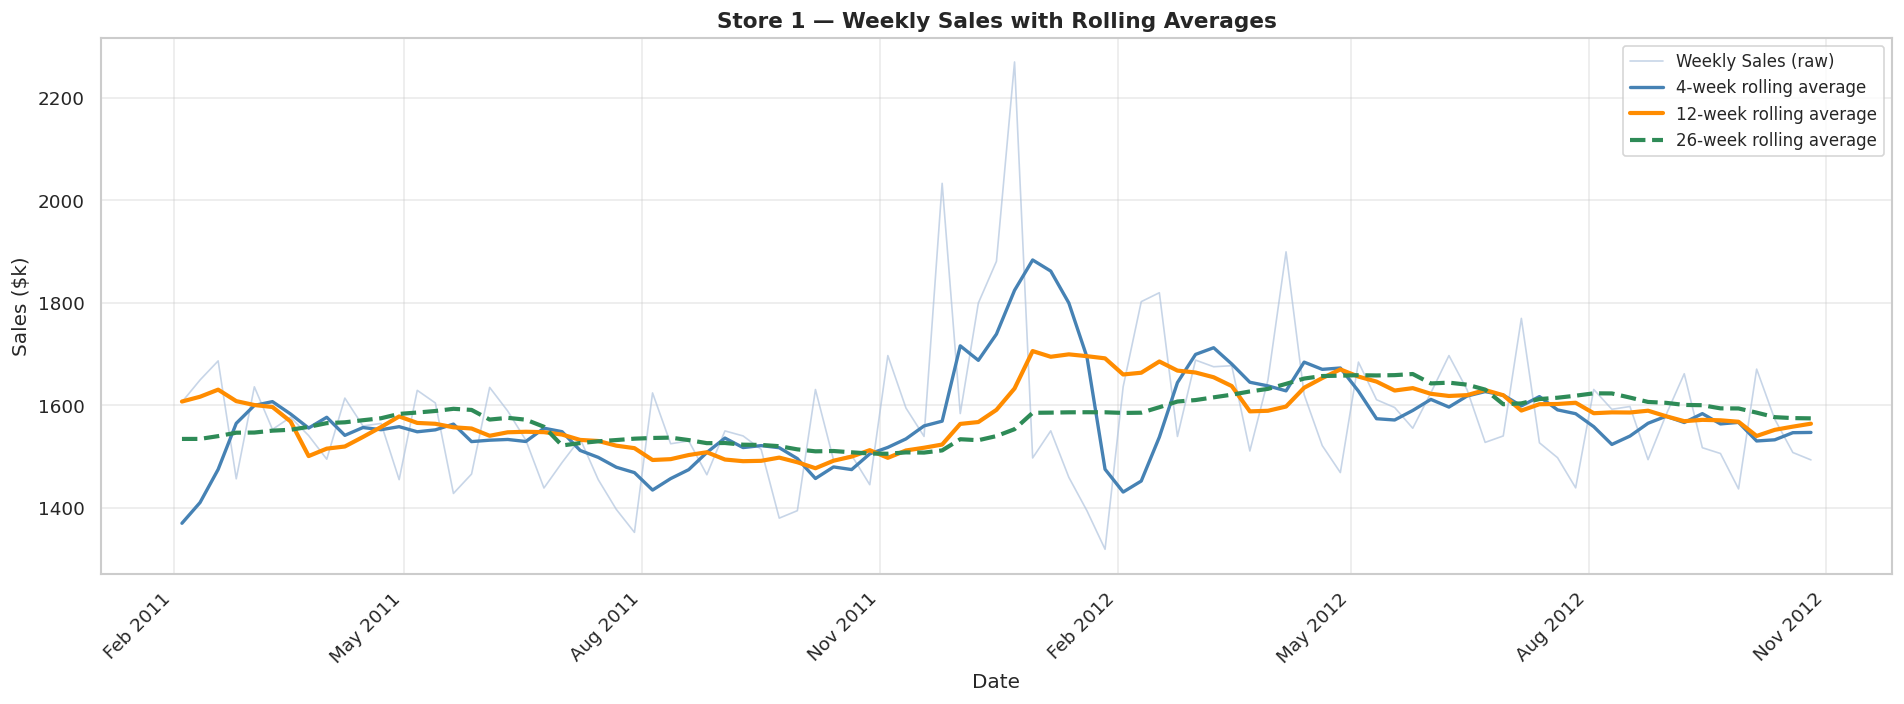

✅ Saved → Google Drive: rolling_averages.png


In [35]:
# Rolling averages smooth out weekly noise to reveal the underlying trend
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(store_df_clean['Date'], store_df_clean['Sales']/1e3,
        color='lightsteelblue', lw=1, alpha=0.7, label='Weekly Sales (raw)')
ax.plot(store_df_clean['Date'], store_df_clean['rolling_mean_4']/1e3,
        color='steelblue', lw=2, label='4-week rolling average')
ax.plot(store_df_clean['Date'], store_df_clean['rolling_mean_12']/1e3,
        color='darkorange', lw=2.5, label='12-week rolling average')
ax.plot(store_df_clean['Date'], store_df_clean['rolling_mean_26']/1e3,
        color='seagreen', lw=2.5, linestyle='--', label='26-week rolling average')

ax.set_title(f"Store {STORE_ID} — Weekly Sales with Rolling Averages",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Date"); ax.set_ylabel("Sales ($k)")
ax.legend(fontsize=10); ax.grid(alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/rolling_averages.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: rolling_averages.png")

Model Comparison

  FINAL MODEL COMPARISON


,MAE,RMSE,MAPE,R2
Model,,,,
Linear Regression,104959.478136,119940.076804,6.791154,-2.012245
Ridge Regression,36874.369678,44927.563166,2.363182,0.577344
Random Forest,37479.968975,43299.495103,2.418957,0.607421
XGBoost,39574.150385,48165.886302,2.583559,0.514219
LightGBM,84390.098282,104307.561669,5.466938,-1.278207


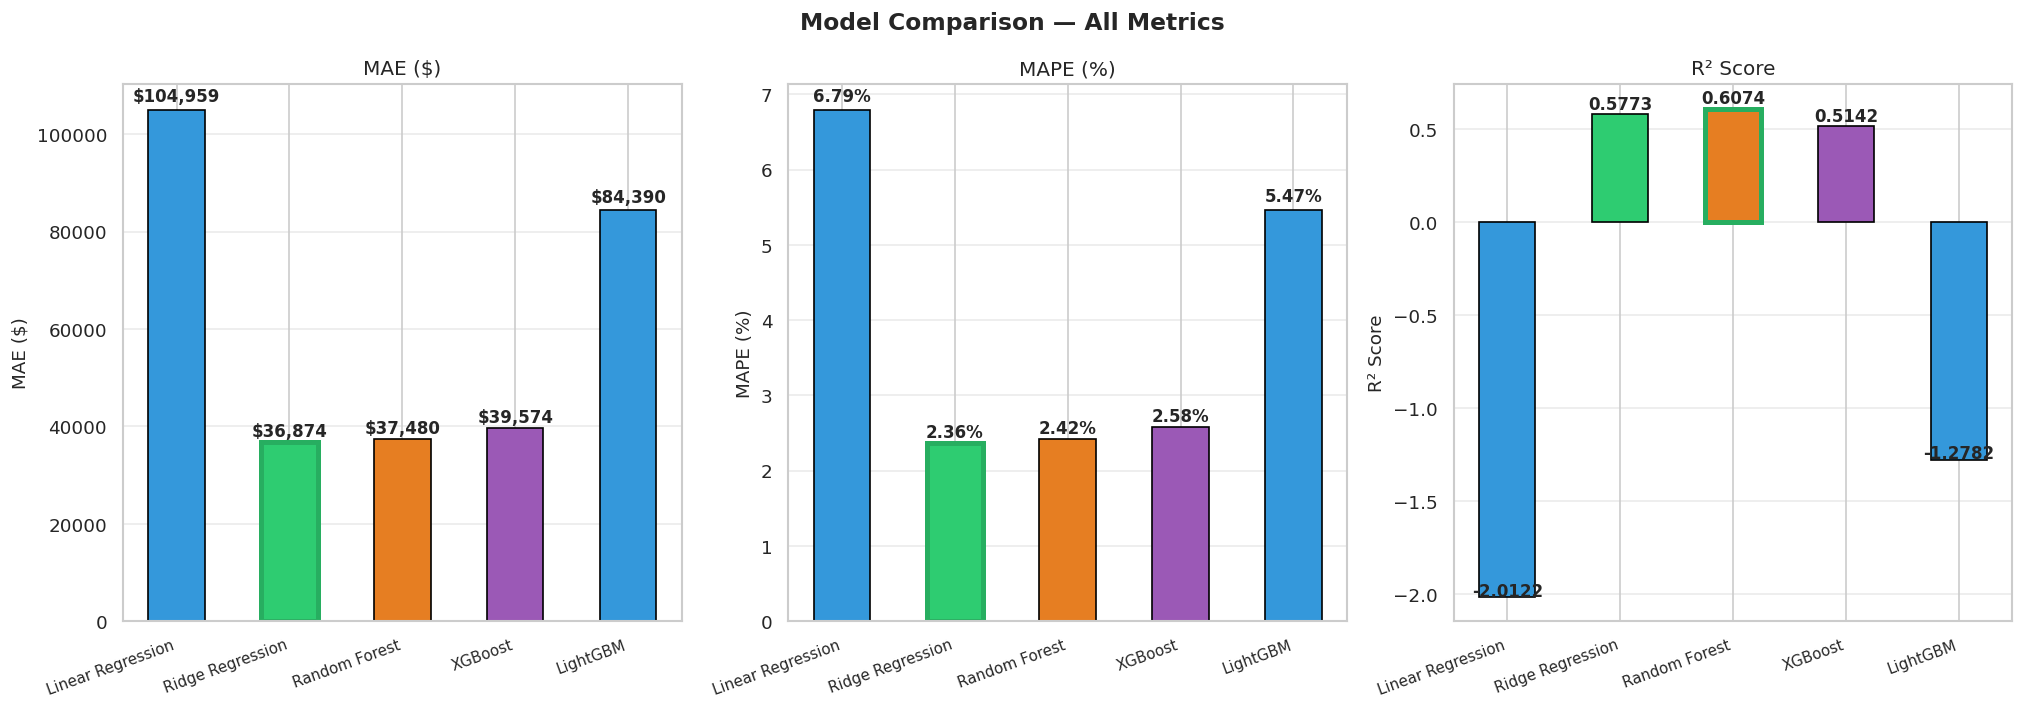

✅ Saved → Google Drive: model_comparison.png

🏆 Best model: Ridge Regression  (MAPE = 2.36%,  R² = 0.5773)


In [36]:
# Build comparison DataFrame
comp_df = pd.DataFrame(RESULTS).T[['MAE','RMSE','MAPE','R2']].round(4)
comp_df.index.name = 'Model'
print("=" * 65)
print("  FINAL MODEL COMPARISON")
print("=" * 65)
display(comp_df)

# ── Bar charts for each metric ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle("Model Comparison — All Metrics", fontsize=14, fontweight='bold')

bar_colors = ['#3498DB','#2ECC71','#E67E22','#9B59B6']
models     = list(RESULTS.keys())

for ax, metric, ylabel, fmt in zip(
    axes,
    ['MAE',  'MAPE',  'R2'],
    ['MAE ($)', 'MAPE (%)', 'R² Score'],
    ['${:,.0f}', '{:.2f}%', '{:.4f}']
):
    vals = [RESULTS[m][metric] for m in models]
    bars = ax.bar(models, vals, color=bar_colors[:len(models)], edgecolor='black', width=0.5)

    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.01,
                fmt.format(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontsize=12)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.4)

    # Highlight best bar in green
    best_idx = vals.index(min(vals)) if metric != 'R2' else vals.index(max(vals))
    bars[best_idx].set_edgecolor('#27AE60')
    bars[best_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/model_comparison.png", bbox_inches='tight')
plt.show()
print("✅ Saved → Google Drive: model_comparison.png")

winner = min(RESULTS, key=lambda k: RESULTS[k]['MAPE'])
print(f"\n🏆 Best model: {winner}  (MAPE = {RESULTS[winner]['MAPE']:.2f}%,  R² = {RESULTS[winner]['R2']:.4f})")